In [1]:
# Ô lệnh do kaggle_run.sh chèn vào — đặt chế độ chạy trước khi notebook đọc biến này.
import os
os.environ['SMOKE_TEST'] = '0'
print('SMOKE_TEST =', os.environ['SMOKE_TEST'], '->', 'thử nhanh' if os.environ['SMOKE_TEST'] == '1' else 'chạy đầy đủ')


SMOKE_TEST = 0 -> chạy đầy đủ


# Lazada Uplift — 05 · Mô hình cần bao nhiêu đặc trưng?

Notebook phụ, chạy **sau** khi bàn giao xong. Nó không sinh ra mô hình nào và không đụng tới `rct_holdout`. Việc duy nhất của nó: trả lời câu hỏi ablation của mentor bằng một phép đo đủ chặt.

### Câu hỏi

> *"Đánh giá tầm quan trọng của đặc trưng để xem khi bớt đi một số trường thông tin thì độ chính xác của mô hình có bị ảnh hưởng nhiều hay không. Thực tế, anh nghĩ chỉ cần tối ưu và giữ lại khoảng 25 đặc trưng quan trọng nhất để đưa lên Redis là đủ hiệu quả."*

Câu hỏi này **không** trả lời được bằng bảng feature importance. Gain chỉ nói *cây dùng cột đó nhiều hay ít*, không nói *bỏ đi thì mất gì*. Cách duy nhất trả lời đúng là bỏ thật rồi huấn luyện lại.

### Vì sao cần notebook riêng thay vì dùng lại vòng quét ở 04b

Vòng quét ở `04b` huấn luyện **một lần cho mỗi mức k**. Với bộ dữ liệu tín hiệu yếu như thế này, một lần huấn luyện là một mẫu ngẫu nhiên: đổi seed của cross-fitting là ra một mô hình khác, và điểm Qini nhảy đi đáng kể. Kết quả là đường cong nhấp nhô, và mỗi điểm trên đó chưa phân biệt được đâu là đặc tính của tập cột, đâu là may rủi của lần chạy.

Notebook này sửa đúng chỗ đó: **mỗi mức k được huấn luyện lại nhiều lần với nhiều seed**, rồi lấy trung bình. Phần dao động giữa các seed chính là *sàn nhiễu* — thước đo không thể phân giải bất kỳ khác biệt nào nhỏ hơn nó.

### Ba thứ được giữ cố định để phép so công bằng

| Cố định | Vì sao |
|---|---|
| Cùng một mẫu 200k dòng cho mọi mức k | Khác cỡ mẫu thì chênh lệch trộn cả "ít cột hơn" lẫn "ít dữ liệu hơn" |
| Cùng bộ siêu tham số | Tinh chỉnh lại cho từng k là một dạng chọn lọc khác, và tốn gấp nhiều lần |
| Cùng thứ tự bỏ cột | Lấy từ permutation importance đã đo ở `04b`, bỏ dần từ cột kém quan trọng nhất |

### Đầu ra

`artifacts/quet_dac_trung.json` và `reports/figures/21_quet_dac_trung.png`

---
# Phần 1 — Thiết lập

### Bước 1 — Import thư viện

In [2]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

import warnings
warnings.filterwarnings('ignore')

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    import glob
    _train_files = glob.glob('/kaggle/input/**/train.parquet', recursive=True)
    if not _train_files:
        raise FileNotFoundError(
            'Không tìm thấy train.parquet trong /kaggle/input. Kiểm tra dataset source.')
    ROOT = '/kaggle/working'
    DATA_DIR = os.path.dirname(_train_files[0])
    ART_DIR = '/kaggle/working/artifacts'
    FIG_DIR = '/kaggle/working/reports/figures'
else:
    ROOT = '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.'
    DATA_DIR = os.path.join(ROOT, 'dataset')
    ART_DIR = os.path.join(ROOT, 'artifacts')
    FIG_DIR = os.path.join(ROOT, 'reports', 'figures')

os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


def tim_file(ten):
    '''Tìm artifact local hoặc trong output của kernel nguồn trên Kaggle.'''
    ung_vien = [os.path.join(ART_DIR, ten)]
    if IS_KAGGLE:
        ung_vien += sorted(glob.glob(f'/kaggle/input/**/{ten}', recursive=True))
    ung_vien = [p for p in ung_vien if os.path.exists(p)]
    if not ung_vien:
        raise FileNotFoundError(
            f'Không tìm thấy {ten}. Kiểm tra kernel_sources của notebook 05.')
    if len(ung_vien) > 1:
        print(f'!!! Có {len(ung_vien)} bản {ten}; đang dùng: {ung_vien[0]}')
    return ung_vien[0]

SEED = 42
TRAPZ = getattr(np, 'trapezoid', None) or np.trapz

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print('Môi trường:', 'Kaggle' if IS_KAGGLE else 'Local')
print('DATA_DIR :', DATA_DIR)
print('ART_DIR  :', ART_DIR)

Môi trường: Kaggle
DATA_DIR : /kaggle/input/datasets/hatrungkienhatuki/lazada-uplift-data
ART_DIR  : /kaggle/working/artifacts


### Bước 2 — Chế độ chạy

`TOL` là **dung sai** — mức tụt Qini mà ta chấp nhận đánh đổi để bớt cột. Đây là con số duy nhất do người quyết định, và phải nói rõ trong báo cáo. Mọi thứ còn lại do dữ liệu trả lời.

Chế độ đầy đủ chạy khoảng 15 phút: 14 mức k × 5 seed = 70 lần huấn luyện DR-Learner.

In [3]:
SMOKE_TEST = os.environ.get('SMOKE_TEST', '1').lower() not in ('0', 'false', 'no')

TOL = 0.01          # dung sai: chấp nhận Qini tụt tối đa ngần này khi bớt cột

if SMOKE_TEST:
    K_GRID = [69, 40, 20]
    SEEDS = [42, 1]
    N_FIT_QUET = 50_000
else:
    K_GRID = [69, 65, 61, 57, 53, 49, 45, 40, 35, 30, 25, 20, 15, 10]
    SEEDS = [42, 1, 7, 13, 23]
    N_FIT_QUET = 200_000

RUN_MODE = 'smoke_test' if SMOKE_TEST else 'full'

print('=' * 66)
print(f'  05 — QUÉT SỐ ĐẶC TRƯNG   |   CHẾ ĐỘ: {RUN_MODE.upper()}')
print(f'  Dung sai chấp nhận : Qini tụt tối đa {TOL}')
print(f'  Lưới k             : {K_GRID}')
print(f'  Số seed mỗi mức    : {len(SEEDS)}  -> tổng {len(K_GRID)*len(SEEDS)} lần huấn luyện')
print(f'  Cỡ mẫu mỗi lần     : {N_FIT_QUET:,} dòng')
if SMOKE_TEST:
    print('  >>> CHỈ ĐỂ KIỂM TRA CODE, KHÔNG DÙNG BÁO CÁO <<<')
print('=' * 66)

  05 — QUÉT SỐ ĐẶC TRƯNG   |   CHẾ ĐỘ: FULL
  Dung sai chấp nhận : Qini tụt tối đa 0.01
  Lưới k             : [69, 65, 61, 57, 53, 49, 45, 40, 35, 30, 25, 20, 15, 10]
  Số seed mỗi mức    : 5  -> tổng 70 lần huấn luyện
  Cỡ mẫu mỗi lần     : 200,000 dòng


### Bước 3 — Nạp dữ liệu và thứ tự bỏ cột

Thứ tự bỏ cột lấy từ **permutation importance** đã đo ở `04b` trên mô hình quán quân: xáo ngẫu nhiên từng cột rồi xem Qini tụt bao nhiêu. Cột tụt ít nhất bị bỏ trước.

Không nạp `rct_holdout.parquet`. Notebook này chỉ đo trên `rct_select`.

In [4]:
tuning = json.load(open(tim_file('best_params.json'), encoding='utf-8'))
P_DR = tuning['best_params']['DRLearner']['params']
E_ALPHA = float(tuning['xu_ly_overlap']['propensity_alpha'])
E_CLIP = (E_ALPHA, 1 - E_ALPHA)

select_meta = json.load(open(tim_file('04b_select_meta.json'), encoding='utf-8'))
HANG = select_meta['permutation_importance']['hang']
QUAN_QUAN = select_meta['quan_quan']

finfo = json.load(open(tim_file('feature_info.json'), encoding='utf-8'))
FEATS = finfo['tat_ca_dac_trung']
N_FEAT = len(FEATS)
XEP_HANG = sorted(FEATS, key=lambda f: HANG[f])      # quan trọng nhất đứng đầu

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
rct_sel = pd.read_parquet(os.path.join(DATA_DIR, 'rct_select.parquet'))
full = pd.concat([train, val], ignore_index=True)

X_full = full[FEATS].values.astype(np.float32)
W_full, Y_full = full['is_treat'].values, full['label'].values
X_sel = rct_sel[FEATS].values.astype(np.float32)
y_sel, w_sel = rct_sel['label'].values, rct_sel['is_treat'].values

assert N_FEAT == 69 and not any(f.startswith('fe_') for f in FEATS)
assert max(K_GRID) == N_FEAT, 'Lưới phải có mốc đầy đủ để làm mốc so sánh'

print(f'Mô hình quán quân   : {QUAN_QUAN}')
print(f'Đặc trưng           : {N_FEAT}')
print(f'Train + Val         : {len(full):,} dòng')
print(f'rct_select          : {len(rct_sel):,} dòng')
print('rct_holdout         : KHÔNG nạp')
print()
print('10 cột bị bỏ đầu tiên (kém quan trọng nhất):', XEP_HANG[-10:][::-1])
print('10 cột giữ tới cuối  (quan trọng nhất)     :', XEP_HANG[:10])

Mô hình quán quân   : DRLearner
Đặc trưng           : 69
Train + Val         : 926,669 dòng
rct_select          : 90,834 dòng
rct_holdout         : KHÔNG nạp

10 cột bị bỏ đầu tiên (kém quan trọng nhất): ['f30', 'f68', 'f20', 'f52', 'f82', 'f21', 'f45', 'f43', 'f56', 'f6']
10 cột giữ tới cuối  (quan trọng nhất)     : ['f23', 'f17', 'f22', 'f79', 'f13', 'f38', 'f12', 'f0', 'f31', 'f35']


---
# Phần 2 — Dựng phép đo

### Bước 4 — Mẫu cố định

Lấy một mẫu phân tầng theo `(is_treat, label)` **một lần duy nhất**, rồi dùng lại cho mọi mức k và mọi seed. Nhờ vậy chênh lệch giữa các mức k chỉ đến từ tập cột, không lẫn dao động do bốc mẫu.

In [5]:
rng_mau = np.random.RandomState(SEED)
strata = W_full * 2 + Y_full
_idx = []
for s in np.unique(strata):
    pos = np.where(strata == s)[0]
    n = max(1, int(round(N_FIT_QUET * len(pos) / len(full))))
    _idx.append(rng_mau.choice(pos, size=min(n, len(pos)), replace=False))
IDX = np.sort(np.concatenate(_idx))

print(f'Mẫu cố định: {len(IDX):,} dòng | treat {W_full[IDX].mean()*100:.2f}% '
      f'| mua {Y_full[IDX].mean()*100:.2f}%')
print(f'(toàn tập  : {len(full):,} dòng | treat {W_full.mean()*100:.2f}% '
      f'| mua {Y_full.mean()*100:.2f}%)')

Mẫu cố định: 200,000 dòng | treat 22.17% | mua 1.99%
(toàn tập  : 926,669 dòng | treat 22.17% | mua 1.99%)


### Bước 5 — DR-Learner và hệ số Qini

Chép lại đúng định nghĩa của `04b` để notebook này chạy độc lập. `seed` được truyền vào tận nơi: nó quyết định cách chia fold khi cross-fitting và seed của LightGBM — tức là quyết định *mô hình cụ thể* nào được sinh ra từ cùng một tập dữ liệu.

In [6]:
def fit_drlearner(X, W, Y, seed, n_folds=5):
    n = len(X)
    e_hat, mu0, mu1 = np.zeros(n), np.zeros(n), np.zeros(n)
    par = dict(n_estimators=200, learning_rate=0.05, max_depth=5,
               min_child_samples=50, random_state=seed, verbose=-1)

    for tr, te in StratifiedKFold(n_folds, shuffle=True, random_state=seed).split(X, W * 2 + Y):
        e_hat[te] = np.clip(
            lgb.LGBMClassifier(**par).fit(X[tr], W[tr]).predict_proba(X[te])[:, 1], *E_CLIP)
        mu0[te] = lgb.LGBMClassifier(**par).fit(
            X[tr][W[tr] == 0], Y[tr][W[tr] == 0]).predict_proba(X[te])[:, 1]
        mu1[te] = lgb.LGBMClassifier(**par).fit(
            X[tr][W[tr] == 1], Y[tr][W[tr] == 1]).predict_proba(X[te])[:, 1]

    dr = (mu1 - mu0) + W * (Y - mu1) / e_hat - (1 - W) * (Y - mu0) / (1 - e_hat)
    return lgb.LGBMRegressor(**P_DR, random_state=seed, verbose=-1).fit(X, dr)


def _sap_xep(y, w, score, seed=SEED):
    rng = np.random.RandomState(seed)
    order = np.lexsort((rng.rand(len(y)), -np.asarray(score, dtype=float)))
    y_, w_ = np.asarray(y)[order], np.asarray(w)[order]
    return np.cumsum(w_), np.cumsum(1 - w_), np.cumsum(y_ * w_), np.cumsum(y_ * (1 - w_))


def qini_tho(y, w, score):
    nt, nc, yt, yc = _sap_xep(y, w, score)
    n = len(y)
    g = (yt - yc * np.divide(nt, nc, out=np.zeros(n), where=nc > 0)) / n
    return float(TRAPZ(g, np.arange(1, n + 1) / n) - 0.5 * g[-1])


def qini_score(y, w, score):
    oracle = np.where(np.asarray(w) == 1, y, -np.asarray(y)).astype(float)
    tran = qini_tho(y, w, oracle)
    return qini_tho(y, w, score) / tran if tran > 0 else np.nan


print('Đã định nghĩa fit_drlearner và qini_score')

Đã định nghĩa fit_drlearner và qini_score


---
# Phần 3 — Chạy quét

### Bước 6 — Mỗi mức k, huấn luyện lại với từng seed

Cắt cột thì **giữ nguyên thứ tự `FEATS` gốc**, không xếp lại theo độ quan trọng. LightGBM khi gặp hai điểm chia ngang tài sẽ lấy cột đứng trước trong danh sách, mà nhãn DR-score nhiễu nặng nên thế ngang tài xảy ra liên tục — xếp lại cột là một hoán vị chẳng mang thông tin gì nhưng đủ làm mô hình khác đi.

In [7]:
ket_qua = []
t_bat_dau = time.time()

for k in K_GRID:
    giu = set(XEP_HANG[:k])
    ik = [i for i, f in enumerate(FEATS) if f in giu]        # thứ tự cột gốc
    qs = []
    for sd in SEEDS:
        m = fit_drlearner(X_full[np.ix_(IDX, ik)], W_full[IDX], Y_full[IDX], sd)
        qs.append(qini_score(y_sel, w_sel, m.predict(X_sel[:, ik])))
    ket_qua.append({'k': k, 'bo': N_FEAT - k, 'Qini_TB': float(np.mean(qs)),
                    'sd_seed': float(np.std(qs)), 'thap_nhat': float(min(qs)),
                    'cao_nhat': float(max(qs)), 'qini_tung_seed': [float(q) for q in qs]})
    print(f'  k = {k:>3} | TB {np.mean(qs):+.4f} | sd giữa các seed {np.std(qs):.4f} '
          f'| [{min(qs):+.4f} .. {max(qs):+.4f}] | {time.time()-t_bat_dau:.0f}s', flush=True)

df = pd.DataFrame(ket_qua).sort_values('k', ascending=False).reset_index(drop=True)
q_day_du = float(df.loc[df.k == N_FEAT, 'Qini_TB'].iloc[0])
df['lech_so_voi_day_du'] = q_day_du - df['Qini_TB']
df['trong_dung_sai'] = df['lech_so_voi_day_du'] <= TOL

print(f'\nXong sau {(time.time()-t_bat_dau)/60:.1f} phút.')

  k =  69 | TB +0.0257 | sd giữa các seed 0.0040 | [+0.0210 .. +0.0308] | 241s
  k =  65 | TB +0.0114 | sd giữa các seed 0.0086 | [+0.0008 .. +0.0217] | 474s
  k =  61 | TB +0.0144 | sd giữa các seed 0.0076 | [+0.0077 .. +0.0291] | 697s
  k =  57 | TB +0.0166 | sd giữa các seed 0.0054 | [+0.0093 .. +0.0252] | 916s
  k =  53 | TB +0.0169 | sd giữa các seed 0.0058 | [+0.0069 .. +0.0232] | 1132s
  k =  49 | TB +0.0165 | sd giữa các seed 0.0105 | [-0.0000 .. +0.0288] | 1338s
  k =  45 | TB +0.0197 | sd giữa các seed 0.0062 | [+0.0127 .. +0.0290] | 1537s
  k =  40 | TB +0.0225 | sd giữa các seed 0.0069 | [+0.0122 .. +0.0332] | 1730s
  k =  35 | TB +0.0218 | sd giữa các seed 0.0057 | [+0.0149 .. +0.0303] | 1922s
  k =  30 | TB +0.0245 | sd giữa các seed 0.0057 | [+0.0174 .. +0.0324] | 2109s
  k =  25 | TB +0.0126 | sd giữa các seed 0.0048 | [+0.0041 .. +0.0171] | 2286s
  k =  20 | TB +0.0062 | sd giữa các seed 0.0030 | [+0.0022 .. +0.0106] | 2448s
  k =  15 | TB -0.0033 | sd giữa các seed 0.

### Bước 7 — Sàn nhiễu: thước đo này phân giải được tới đâu

Trước khi đọc bảng kết quả phải biết thước đo nhạy tới mức nào. Cột `sd_seed` là độ lệch chuẩn của Qini khi **giữ nguyên tập cột** mà chỉ đổi seed. Đó là dao động thuần túy của quá trình huấn luyện, không liên quan gì tới việc bớt cột.

Nếu dung sai `TOL` nhỏ hơn sàn nhiễu này thì mọi kết luận dạng *"bớt cột chỉ lệch dưới TOL"* đều nằm ngoài khả năng của phép đo.

In [8]:
san_nhieu = float(df['sd_seed'].mean())
se_tb = san_nhieu / np.sqrt(len(SEEDS))

print(f'Dao động Qini khi chỉ đổi seed (trung bình mọi mức k): ±{san_nhieu:.4f}')
print(f'Sai số chuẩn của trung bình {len(SEEDS)} seed              : ±{se_tb:.4f}')
print(f'Dung sai đang dùng                                  :  {TOL:.4f}')
print()
if TOL < san_nhieu:
    print('=> Dung sai NHỎ HƠN dao động của chính phép huấn luyện.')
    print('   Trung bình nhiều seed vẫn dùng được, nhưng từng lần chạy riêng lẻ sẽ nhảy')
    print('   quanh mức trung bình một khoảng lớn hơn cả dung sai. Phải nói rõ điều này.')
else:
    print('=> Dung sai lớn hơn sàn nhiễu, phép so ở dưới có nghĩa.')

Dao động Qini khi chỉ đổi seed (trung bình mọi mức k): ±0.0057
Sai số chuẩn của trung bình 5 seed              : ±0.0025
Dung sai đang dùng                                  :  0.0100

=> Dung sai lớn hơn sàn nhiễu, phép so ở dưới có nghĩa.


---
# Phần 4 — Kết quả

### Bước 8 — Bảng đầy đủ

In [9]:
hien = df[['k', 'bo', 'Qini_TB', 'sd_seed', 'thap_nhat', 'cao_nhat',
           'lech_so_voi_day_du', 'trong_dung_sai']].copy()
hien.columns = ['Giữ', 'Bỏ', 'Qini TB', 'sd giữa seed', 'Thấp nhất', 'Cao nhất',
                'Lệch so với đầy đủ', f'Trong dung sai {TOL}']
display(hien.round(4))

dat = df[df['trong_dung_sai'] & (df['k'] < N_FEAT)]
if len(dat):
    K_CHOT = int(dat['k'].min())
    r = df[df['k'] == K_CHOT].iloc[0]
    print(f'Mức nhỏ nhất còn nằm trong dung sai {TOL}: k = {K_CHOT} '
          f'(bỏ {N_FEAT - K_CHOT}/{N_FEAT} cột)')
    print(f'  Qini trung bình {r.Qini_TB:+.4f} so với {q_day_du:+.4f} của bản đầy đủ '
          f'-> lệch {r.lech_so_voi_day_du:.4f}')
else:
    K_CHOT = N_FEAT
    print(f'Không mức nào nằm trong dung sai {TOL} — giữ nguyên toàn bộ {N_FEAT} đặc trưng.')

,Giữ,Bỏ,Qini TB,sd giữa seed,Thấp nhất,Cao nhất,Lệch so với đầy đủ,Trong dung sai 0.01
0,69,0,0.0257,0.0040,0.0210,0.0308,0.0000,True
1,65,4,0.0114,0.0086,0.0008,0.0217,0.0143,False
2,61,8,0.0144,0.0076,0.0077,0.0291,0.0112,False
3,57,12,0.0166,0.0054,0.0093,0.0252,0.0091,True
4,53,16,0.0169,0.0058,0.0069,0.0232,0.0088,True
5,49,20,0.0165,0.0105,-0.0000,0.0288,0.0092,True
6,45,24,0.0197,0.0062,0.0127,0.0290,0.0059,True
7,40,29,0.0225,0.0069,0.0122,0.0332,0.0032,True
8,35,34,0.0218,0.0057,0.0149,0.0303,0.0039,True
9,30,39,0.0245,0.0057,0.0174,0.0324,0.0012,True


Mức nhỏ nhất còn nằm trong dung sai 0.01: k = 30 (bỏ 39/69 cột)
  Qini trung bình +0.0245 so với +0.0257 của bản đầy đủ -> lệch 0.0012


### Bước 9 — Đường cong

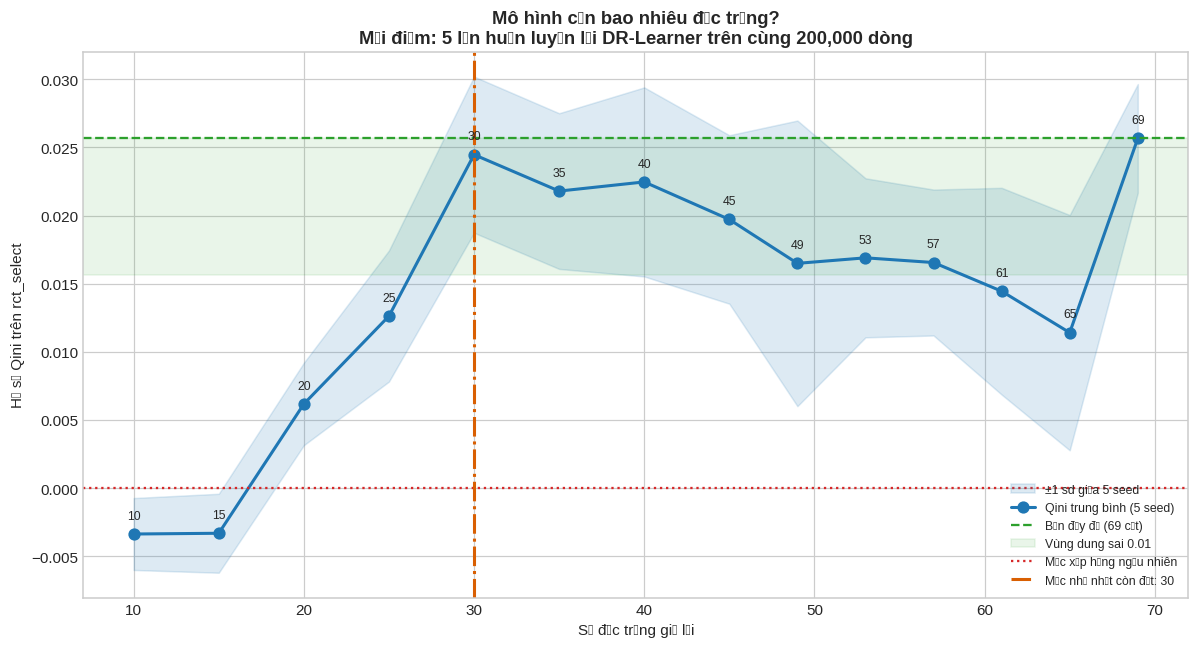

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

d = df.sort_values('k')
ax.fill_between(d['k'], d['Qini_TB'] - d['sd_seed'], d['Qini_TB'] + d['sd_seed'],
                color='#1f77b4', alpha=0.15, label=f'±1 sd giữa {len(SEEDS)} seed')
ax.plot(d['k'], d['Qini_TB'], 'o-', color='#1f77b4', lw=2, ms=7,
        label=f'Qini trung bình ({len(SEEDS)} seed)')

ax.axhline(q_day_du, color='#2ca02c', ls='--', lw=1.5, label=f'Bản đầy đủ ({N_FEAT} cột)')
ax.axhspan(q_day_du - TOL, q_day_du, color='#2ca02c', alpha=0.10,
           label=f'Vùng dung sai {TOL}')
ax.axhline(0, color='#d62728', ls=':', lw=1.5, label='Mức xếp hạng ngẫu nhiên')

if K_CHOT < N_FEAT:
    ax.axvline(K_CHOT, color='#d95f02', ls='-.', lw=2, label=f'Mức nhỏ nhất còn đạt: {K_CHOT}')

for _, r in d.iterrows():
    ax.annotate(f"{int(r.k)}", (r.k, r.Qini_TB), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8)

ax.set_xlabel('Số đặc trưng giữ lại')
ax.set_ylabel('Hệ số Qini trên rct_select')
ax.set_title('Mô hình cần bao nhiêu đặc trưng?\n'
             f'Mỗi điểm: {len(SEEDS)} lần huấn luyện lại DR-Learner trên cùng {len(IDX):,} dòng')
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '21_quet_dac_trung.png'), bbox_inches='tight')
plt.show()

### Bước 10 — Đọc đường cong cho đúng

Ba vùng, và chỉ vùng đầu là kết luận chắc chắn:

1. **Vùng sập** — dưới một ngưỡng nào đó Qini rơi về 0 hoặc âm, tức mô hình xếp hạng không hơn bốc ngẫu nhiên. Khoảng cách tới bản đầy đủ lớn hơn nhiều lần sàn nhiễu, nên đây là kết luận chắc.
2. **Vùng bằng phẳng** — các mức k ở đây có trung bình chênh nhau ít hơn hoặc xấp xỉ sàn nhiễu. **Không phân biệt được với nhau.**
3. **Bản đầy đủ** — nằm trong vùng 2, không tách khỏi các mức thấp hơn.

Hệ quả về cách phát biểu, và đây là chỗ dễ nói quá nhất:

| Nói thế này | Đúng/Sai |
|---|---|
| *"Bỏ 39 cột mà mô hình vẫn tốt như cũ"* | **Sai** — phép đo không chứng minh được "tốt như cũ" |
| *"Phép đo không phân biệt được bản 30 cột với bản 69 cột"* | Đúng |
| *"Dưới 25 cột thì mô hình mất tín hiệu"* | Đúng, nếu đường cong cho thấy vùng sập ở đó |

Ô lệnh dưới in ra khoảng cách giữa từng mức và sàn nhiễu, để phân vùng bằng số chứ không bằng mắt.

In [11]:
d = df.sort_values('k', ascending=False).copy()
d['gap_tren_san_nhieu'] = d['lech_so_voi_day_du'] / san_nhieu

def phan_vung(r):
    if r['k'] == N_FEAT:
        return 'bản đầy đủ'
    if r['gap_tren_san_nhieu'] <= 1:
        return 'không phân biệt được'
    if r['gap_tren_san_nhieu'] <= 2:
        return 'nghi ngờ kém hơn'
    return 'kém hơn rõ rệt'

d['ket_luan'] = d.apply(phan_vung, axis=1)
display(d[['k', 'bo', 'Qini_TB', 'lech_so_voi_day_du', 'gap_tren_san_nhieu', 'ket_luan']]
        .round(4).rename(columns={'gap_tren_san_nhieu': 'lệch / sàn nhiễu'}))

print(f'Sàn nhiễu = ±{san_nhieu:.4f} (dao động khi chỉ đổi seed)')
print('Cột "lệch / sàn nhiễu" nhỏ hơn 1 nghĩa là chênh lệch còn nhỏ hơn dao động nội tại')
print('của chính quá trình huấn luyện — không thể quy cho việc bớt cột.')

,k,bo,Qini_TB,lech_so_voi_day_du,lệch / sàn nhiễu,ket_luan
0,69,0,0.0257,0.0000,0.0000,bản đầy đủ
1,65,4,0.0114,0.0143,2.5008,kém hơn rõ rệt
2,61,8,0.0144,0.0112,1.9671,nghi ngờ kém hơn
3,57,12,0.0166,0.0091,1.5979,nghi ngờ kém hơn
4,53,16,0.0169,0.0088,1.5373,nghi ngờ kém hơn
5,49,20,0.0165,0.0092,1.6084,nghi ngờ kém hơn
6,45,24,0.0197,0.0059,1.0435,nghi ngờ kém hơn
7,40,29,0.0225,0.0032,0.5602,không phân biệt được
8,35,34,0.0218,0.0039,0.6781,không phân biệt được
9,30,39,0.0245,0.0012,0.2090,không phân biệt được


Sàn nhiễu = ±0.0057 (dao động khi chỉ đổi seed)
Cột "lệch / sàn nhiễu" nhỏ hơn 1 nghĩa là chênh lệch còn nhỏ hơn dao động nội tại
của chính quá trình huấn luyện — không thể quy cho việc bớt cột.


---
# Phần 5 — Chốt và bàn giao

### Bước 11 — Danh sách đặc trưng ở mức chốt

Danh sách luôn theo **thứ tự cột gốc** `f0 → f82`, khớp đúng cách mô hình được huấn luyện.

In [12]:
giu = set(XEP_HANG[:K_CHOT])
FEAT_CHOT = [f for f in FEATS if f in giu]
FEAT_BO = [f for f in FEATS if f not in giu]

print(f'GIỮ {len(FEAT_CHOT)} cột:')
print(', '.join(FEAT_CHOT))
print()
print(f'BỎ {len(FEAT_BO)} cột:')
print(', '.join(FEAT_BO) if FEAT_BO else '(không bỏ cột nào)')

GIỮ 30 cột:
f0, f1, f2, f3, f4, f5, f8, f9, f10, f12, f13, f16, f17, f18, f22, f23, f24, f25, f26, f27, f28, f29, f31, f34, f35, f37, f38, f40, f79, f80

BỎ 39 cột:
f6, f7, f11, f14, f19, f20, f21, f30, f36, f41, f42, f43, f44, f45, f46, f47, f48, f49, f50, f51, f52, f53, f54, f55, f56, f57, f58, f59, f60, f61, f62, f63, f64, f65, f66, f68, f75, f81, f82


### Bước 12 — Ba hệ quả nếu đem mức này đi bàn giao

Đây không phải cảnh báo cho có. Bản đang bàn giao là bản **69 cột**, và đổi sang mức nhỏ hơn kéo theo ba thứ:

1. **Phải huấn luyện lại và thay toàn bộ artifact** — `model.pkl`, `model_booster.txt`, `feature_contract.json`, `golden_predictions.csv`, `metadata.json`.
2. **Con số holdout hiện có thuộc về bản 69 cột.** Đo bản mới trên `rct_holdout` là **lần mở thứ hai**, và con số đó không còn là ước lượng không chệch. Nếu vẫn làm thì báo cáo phải ghi rõ.
3. **Đây là lần chọn thứ hai trên `rct_select`.** Vòng quét ở `04b` đã chọn một lần; chọn thêm lần nữa trên cùng tập làm "lời nguyền người thắng cuộc" nặng thêm — con số trên `rct_select` càng lạc quan hơn thực tế.

Vì vậy notebook này **không** tự động thay artifact. Nó chỉ ghi ra kết quả đo để người đọc quyết định.

In [13]:
ket_qua_json = {
    'run_mode': RUN_MODE,
    'cau_hoi': 'Mô hình cần tối thiểu bao nhiêu đặc trưng?',
    'cach_do': {
        'mo_hinh': QUAN_QUAN,
        'so_dong_moi_lan_huan_luyen': int(len(IDX)),
        'so_seed_moi_muc': len(SEEDS),
        'seeds': SEEDS,
        'thu_tu_bo_cot': 'permutation importance đo ở 04b, bỏ dần từ cột kém quan trọng nhất',
        'tap_do_diem': 'rct_select',
        'giu_co_dinh': ['cùng một mẫu dòng cho mọi mức k', 'cùng bộ siêu tham số',
                        'cùng thứ tự bỏ cột'],
    },
    'dung_sai': TOL,
    'san_nhieu': round(san_nhieu, 5),
    'sai_so_chuan_trung_binh': round(se_tb, 5),
    'qini_ban_day_du': round(q_day_du, 5),
    'k_nho_nhat_trong_dung_sai': int(K_CHOT),
    'dac_trung_o_muc_chot': FEAT_CHOT,
    'dac_trung_bi_bo': FEAT_BO,
    'bang': df[['k', 'bo', 'Qini_TB', 'sd_seed', 'thap_nhat', 'cao_nhat',
                'lech_so_voi_day_du', 'trong_dung_sai']].round(5).to_dict('records'),
    'canh_bao': [
        'Chênh lệch nhỏ hơn san_nhieu không quy được cho việc bớt cột.',
        'Notebook này KHÔNG thay artifact bàn giao. Bản đang giao vẫn là bản 69 cột.',
        'Đo bản rút gọn trên rct_holdout sẽ là lần mở thứ hai của tập đó.',
        'Đây là lần chọn thứ hai trên rct_select — con số ở đây lạc quan hơn thực tế.',
    ],
}

path = os.path.join(ART_DIR, 'quet_dac_trung.json')
with open(path, 'w', encoding='utf-8') as f:
    json.dump(ket_qua_json, f, ensure_ascii=False, indent=2)

print('Đã ghi:', path)
print(f'  dung sai {TOL} -> mức nhỏ nhất còn đạt: {K_CHOT}/{N_FEAT} đặc trưng')
print(f'  sàn nhiễu: ±{san_nhieu:.4f}')
if SMOKE_TEST:
    print('\n>>> ĐANG Ở CHẾ ĐỘ SMOKE TEST — đặt SMOKE_TEST=0 rồi chạy lại để lấy số báo cáo <<<')

Đã ghi: /kaggle/working/artifacts/quet_dac_trung.json
  dung sai 0.01 -> mức nhỏ nhất còn đạt: 30/69 đặc trưng
  sàn nhiễu: ±0.0057


---
## Kết luận

### Đã trả lời được gì

| Câu hỏi | Trả lời |
|---|---|
| Bỏ bớt đặc trưng thì mô hình có kém đi không? | Có, nhưng chỉ khi bỏ xuống dưới ngưỡng sập — xem bảng Bước 10 |
| Mentor gợi ý khoảng 25 đặc trưng, có được không? | Xem mức 25 trong bảng: nếu nó rơi vào vùng "kém hơn rõ rệt" thì câu trả lời là không |
| Vậy giữ bao nhiêu? | Mức nhỏ nhất còn nằm trong dung sai, in ở Bước 8 |

### Điều quan trọng nhất, và nó không nằm ở con số k

Dao động Qini khi **chỉ đổi seed** — giữ nguyên toàn bộ dữ liệu, cột và siêu tham số — có cùng độ lớn với chênh lệch giữa các mức k trong vùng bằng phẳng. Nghĩa là mô hình này **không ổn định**: huấn luyện lại một lần nữa cho ra một bộ xếp hạng khách hàng khác đáng kể.

Điều đó ăn khớp với hai bằng chứng độc lập đã có ở `04c`:

- Quán quân chọn trên `rct_select` lại xếp cuối trên `rct_holdout`
- Tương quan hạng giữa hai tập RCT là số âm

Ba phép đo khác nhau, cùng một kết luận: **thứ hạng cụ thể mà mô hình đưa ra phần lớn là nhiễu**, và đó mới là phát hiện đáng đưa vào báo cáo — mạnh hơn nhiều so với việc chốt một con số k.

### Không được phát biểu

- *"Bỏ N cột mà mô hình vẫn tốt như cũ"* — phép đo chỉ nói không phân biệt được, không nói bằng nhau.
- *"k là số đặc trưng tối ưu"* — không có tối ưu ở đây, chỉ có ngưỡng sập và một vùng bằng phẳng.
- Bất kỳ con số nào từ notebook này như thể nó là kết quả trên tập holdout — toàn bộ đo trên `rct_select`.